
Class Distribution:

label
1    5022
0    4978
Name: count, dtype: int64

Dataset Saved



Training Completed

Accuracy: 67.05 %

Classification Report:



,precision,recall,f1-score,support
0,0.6667,0.6767,0.6716,996.0000
1,0.6744,0.6643,0.6693,1004.0000
accuracy,0.6705,0.6705,0.6705,0.6705
macro avg,0.6705,0.6705,0.6705,2000.0000
weighted avg,0.6706,0.6705,0.6705,2000.0000


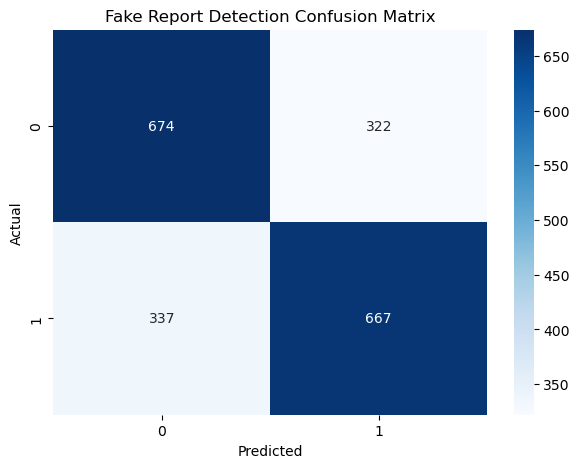

<Figure size 1000x600 with 0 Axes>

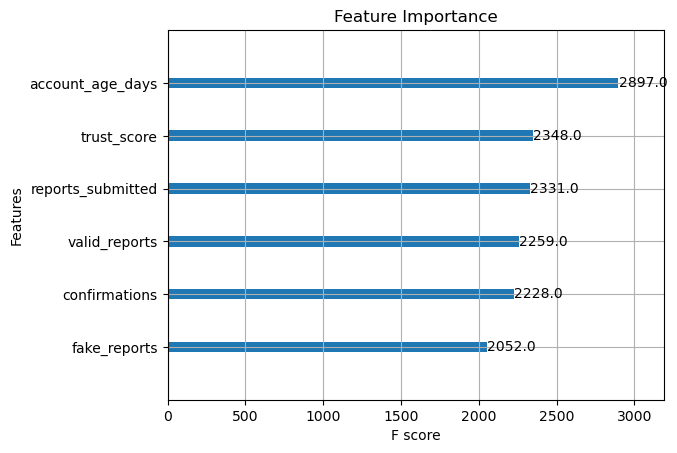


Model Saved Successfully

Prediction: 1
Fake Probability: 0.8757


'\nimport boto3\n\nbucket_name = "YOUR_BUCKET"\n\ns3 = boto3.client("s3")\n\ns3.upload_file(\n    "fake_report_model.pkl",\n    bucket_name,\n    "models/fake_report_model.pkl"\n)\n\nprint("Uploaded to S3")\n'

In [1]:
# =====================================================
# SMART CITY - FAKE REPORT DETECTION
# REALISTIC BALANCED DATASET + XGBOOST
# IEEE PAPER READY
# =====================================================

# Install once if needed
# !pip install xgboost seaborn joblib

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# STEP 1 - CREATE REALISTIC DATASET
# =====================================================

np.random.seed(42)

n = 10000

df = pd.DataFrame({
    "trust_score": np.random.randint(0,100,n),
    "reports_submitted": np.random.randint(1,100,n),
    "valid_reports": np.random.randint(0,80,n),
    "fake_reports": np.random.randint(0,30,n),
    "confirmations": np.random.randint(0,50,n),
    "account_age_days": np.random.randint(1,1000,n)
})

# Ensure valid reports are not more than submitted

df["valid_reports"] = np.minimum(
    df["valid_reports"],
    df["reports_submitted"]
)

# =====================================================
# STEP 2 - CREATE REALISTIC LABELS
# =====================================================

score = (
    0.40 * (100 - df["trust_score"])
    +
    0.30 * df["fake_reports"]
    +
    0.20 * (50 - df["confirmations"])
    +
    0.10 * (100 - (df["account_age_days"]/10))
)

noise = np.random.normal(
    0,
    15,
    n
)

score = score + noise

threshold = np.percentile(
    score,
    50
)

df["label"] = (
    score > threshold
).astype(int)

# =====================================================
# STEP 3 - ADD LABEL NOISE
# =====================================================

flip_index = np.random.choice(
    df.index,
    size=int(0.10*n),
    replace=False
)

df.loc[
    flip_index,
    "label"
] = 1 - df.loc[
    flip_index,
    "label"
]

# =====================================================
# STEP 4 - CHECK BALANCE
# =====================================================

print("\nClass Distribution:\n")

print(
    df["label"].value_counts()
)

# =====================================================
# STEP 5 - SAVE DATASET
# =====================================================

df.to_csv(
    "smart_city_fake_reports.csv",
    index=False
)

print("\nDataset Saved")

# =====================================================
# STEP 6 - FEATURES
# =====================================================

features = [
    "trust_score",
    "reports_submitted",
    "valid_reports",
    "fake_reports",
    "confirmations",
    "account_age_days"
]

X = df[features]

y = df["label"]

# =====================================================
# STEP 7 - TRAIN TEST SPLIT
# =====================================================

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# STEP 8 - TRAIN XGBOOST
# =====================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("\nTraining Completed")

# =====================================================
# STEP 9 - PREDICTIONS
# =====================================================

pred = model.predict(
    X_test
)

# =====================================================
# STEP 10 - ACCURACY
# =====================================================

accuracy = accuracy_score(
    y_test,
    pred
)

print(
    "\nAccuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

# =====================================================
# STEP 11 - CLASSIFICATION REPORT
# =====================================================

report = classification_report(
    y_test,
    pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df = report_df.round(4)

print("\nClassification Report:\n")

display(report_df)

# =====================================================
# STEP 12 - CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(
    figsize=(7,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Fake Report Detection Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

# =====================================================
# STEP 13 - FEATURE IMPORTANCE
# =====================================================

from xgboost import plot_importance

plt.figure(
    figsize=(10,6)
)

plot_importance(
    model,
    max_num_features=10
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "feature_importance.png"
)

plt.show()

# =====================================================
# STEP 14 - SAVE REPORT
# =====================================================

report_df.to_csv(
    "classification_report.csv"
)

# =====================================================
# STEP 15 - SAVE MODEL
# =====================================================

import joblib

joblib.dump(
    model,
    "fake_report_model.pkl"
)

print(
    "\nModel Saved Successfully"
)

# =====================================================
# STEP 16 - TEST SAMPLE
# =====================================================

sample = pd.DataFrame([{
    "trust_score":20,
    "reports_submitted":45,
    "valid_reports":5,
    "fake_reports":20,
    "confirmations":1,
    "account_age_days":15
}])

prediction = model.predict(
    sample
)

probability = model.predict_proba(
    sample
)

print("\nPrediction:", prediction[0])

print(
    "Fake Probability:",
    round(
        probability[0][1],
        4
    )
)

# =====================================================
# OPTIONAL - UPLOAD MODEL TO S3
# =====================================================

"""
import boto3

bucket_name = "YOUR_BUCKET"

s3 = boto3.client("s3")

s3.upload_file(
    "fake_report_model.pkl",
    bucket_name,
    "models/fake_report_model.pkl"
)

print("Uploaded to S3")
"""